/localscratch/tmp/ipykernel_21118/3945103171.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


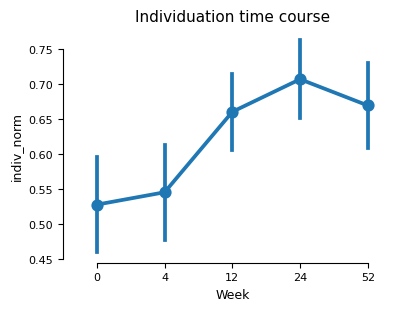

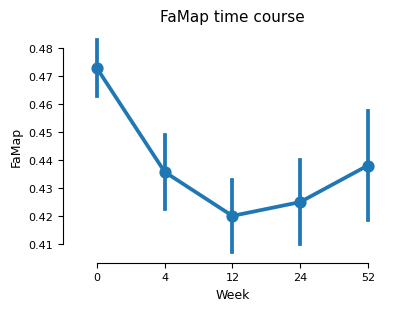

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import smarts_cerebellum.globals as gl

# DTI metrics
dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
dti = dti[dti.isPatient == 1] # just patients


# behavioural metrics
behav = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'summary_paretic.dat'), sep = '\t')
behav.rename(columns = {'subj_name': 'subj_id', 'week': 'Week'}, inplace = True)
behav['subj_id'] = behav['subj_id'].str.strip()
behav.loc[behav['Week']==1, 'Week'] = 0

# affected: ipsilesional CST, paretic hand
fig, ax = plt.subplots(figsize = (4,3), sharey = True, sharex = True, constrained_layout = True)

sns.pointplot(x = 'Week', y = 'indiv_norm', data = behav, ax = ax, errorbar = 'se')


ax.set_ylabel('')
ax.set_xlabel('')

plt.xlabel("Week")
plt.ylabel("indiv_norm")
plt.title("Individuation time course")
sns.despine(trim = True)
plt.show()

# affected: ipsilesional CST, paretic hand
fig, ax = plt.subplots(figsize = (4,3), sharey = True, sharex = True, constrained_layout = True)
dti_plot = dti[(dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]

sns.pointplot(x = 'Week', y = 'mean', data = dti_plot, ax = ax, errorbar = 'se')


ax.set_ylabel('')
ax.set_xlabel('')

plt.xlabel("Week")
plt.ylabel("FaMap")
plt.title("FaMap time course")
sns.despine(trim = True)
plt.show()